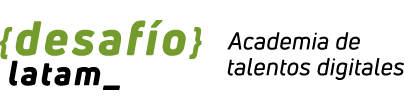

<center><h1> <font color='green'>Indicadores estadísticos con Python</font></h1></center>


### Entornos Virtuales y Kernels en Jupyter

Un error común es pensar que el entorno virtual vive dentro de la libreta .ipynb. En realidad, Jupyter es solo una interfaz (el monitor) que se conecta a un motor de Python llamado Kernel, por lo tanto debemos seguir los siguientes pasos.

* **1. El Flujo de Trabajo**
 
Para crear un entorno y que aparezca en Jupyter, debes seguir estos 4 pasos en tu terminal (CMD o PowerShell):

Los pip de "infraestructura" se hacen en el Shell (PowerShell), y los pip de "librerías de código" se pueden hacer en Jupyter. Pero para que tu entorno  sea ultra estable, lo ideal es hacer todo lo fuerte en el Shell.

* **En Window:**  abrir power shell y llegar a la ruta de la carpeta de trabajo
* **Crear el entorno con:** python -m venv nombre_elegido
* **Activarlo:** .\nombre_elegido\Scripts\activate
* **Instalar el puente (IPyKernel):** pip install ipykernel
* **pegar:** python -m ipykernel install --user --name=venv_rag --display-name nombre_elegido
* **Instalar la base:** pip install jupyter (Solo si no lo habías hecho antes en ese venv)

In [ ]:
python -m venv G122_clase_18_02_2026
.\G122_clase_18_02_2026\Scripts\activate
pip install ipykernel
python -m ipykernel install --user --name=venv_rag --display-name G122_clase_18_02_2026
pip install jupyter

Comandos CLI

* python --version
* python script.py
* python -m venv env
* pip install <nombre>
* pip freeze > requirements.txt
* pip install -r requirements.txt
* python -m pip install -U pip
* python -m http.server
* ls (o dir en Windows)
* cd <nombre_carpeta>

 # <font color='green'>Indicadores en DataFrames</font>

Hemos utilizado anteriormente el método **describe()** para calcular indicadores estadísticos. Veremos a continuación su uso.

In [6]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [1]:
import sys
print(sys.version)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [32]:
#!pip install XXX

import pandas as pd

autos = pd.read_csv('carsales.csv',delimiter=',')
autos.head(3)

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.5,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.4,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN


In [34]:
autos.columns

Index(['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value',
       'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity',
       'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor'],
      dtype='object')

In [37]:
# Diccionario de traducción
columnas_espanol = {
    'Manufacturer': 'Fabricante',
    'Model': 'Modelo',
    'Sales_in_thousands': 'Ventas_en_miles',
    '__year_resale_value': 'Valor_reventa_anio',
    'Vehicle_type': 'Tipo_vehiculo',
    'Price_in_thousands': 'Precio_en_miles',
    'Engine_size': 'Tamano_motor',
    'Horsepower': 'Caballos_fuerza',
    'Wheelbase': 'Distancia_entre_ejes',
    'Width': 'Ancho',
    'Length': 'Largo',
    'Curb_weight': 'Peso_vacio',
    'Fuel_capacity': 'Capacidad_combustible',
    'Fuel_efficiency': 'Eficiencia_combustible',
    'Latest_Launch': 'Ultimo_lanzamiento',
    'Power_perf_factor': 'Factor_rendimiento_potencia'
}

# Renombrar columnas
autos.rename(columns=columnas_espanol, inplace=True)

autos.head(3)

,Fabricante,Modelo,Ventas_en_miles,Valor_reventa_anio,Tipo_vehiculo,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Ultimo_lanzamiento,Factor_rendimiento_potencia
0,Acura,Integra,16.919,16.360,Passenger,21.5,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.4,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN


In [39]:
# Definir valor del dólar hoy (referencia: $862 CLP)
valor_dolar = 862

# Crear la nueva columna convirtiendo las ventas (asumiendo que están en USD)
# Multiplicamos por 1000 porque la columna original está 'en miles'
autos['Ventas_CLP'] = autos['Ventas_en_miles'] * 1000 * valor_dolar
autos['Ventas_CLP'] = autos['Ventas_CLP'].astype("int")

# Revisión rápida de las primeras filas
print(autos[['Ventas_en_miles', 'Ventas_CLP']].head())

   Ventas_en_miles  Ventas_CLP
0           16.919    14584178
1           39.384    33949008
2           14.114    12166268
3            8.588     7402856
4           20.397    17582214


In [41]:
autos.head(5)

,Fabricante,Modelo,Ventas_en_miles,Valor_reventa_anio,Tipo_vehiculo,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Ultimo_lanzamiento,Factor_rendimiento_potencia,Ventas_CLP
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150,14584178
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778,33949008
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN,12166268
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779,7402856
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639,17582214


In [43]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Fabricante                   157 non-null    object 
 1   Modelo                       157 non-null    object 
 2   Ventas_en_miles              157 non-null    float64
 3   Valor_reventa_anio           121 non-null    float64
 4   Tipo_vehiculo                157 non-null    object 
 5   Precio_en_miles              155 non-null    float64
 6   Tamano_motor                 156 non-null    float64
 7   Caballos_fuerza              156 non-null    float64
 8   Distancia_entre_ejes         156 non-null    float64
 9   Ancho                        156 non-null    float64
 10  Largo                        156 non-null    float64
 11  Peso_vacio                   155 non-null    float64
 12  Capacidad_combustible        156 non-null    float64
 13  Eficiencia_combustib

In [45]:
# 1. Extraer la columna (se elimina de su posición actual y se guarda en la variable)
col_clp = autos.pop('Ventas_CLP')

In [47]:
col_clp

0      14584178
1      33949008
2      12166268
3       7402856
4      17582214
         ...   
152     3055790
153    13141190
154    15111722
155     3010966
156    16351278
Name: Ventas_CLP, Length: 157, dtype: int32

In [49]:
# 2. Insertar en la posición [3] (índice 3 es la cuarta columna)
autos.insert(3, 'Ventas_CLP', col_clp)

# Verificar el resultado
# Resaltar el encabezado en negrita visualmente

autos.head(3)

,Fabricante,Modelo,Ventas_en_miles,Ventas_CLP,Valor_reventa_anio,Tipo_vehiculo,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Ultimo_lanzamiento,Factor_rendimiento_potencia
0,Acura,Integra,16.919,14584178,16.360,Passenger,21.5,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,33949008,19.875,Passenger,28.4,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,12166268,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN


In [51]:
# Aplicar negrita a los datos de la columna Ventas_CLP
autos.style.format({'Ventas_CLP': '{:,.0f}'}).set_properties(subset=['Ventas_CLP'], **{'font-weight': 'bold'})
autos.head()

,Fabricante,Modelo,Ventas_en_miles,Ventas_CLP,Valor_reventa_anio,Tipo_vehiculo,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Ultimo_lanzamiento,Factor_rendimiento_potencia
0,Acura,Integra,16.919,14584178,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,33949008,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,12166268,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,7402856,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,17582214,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [67]:
autos.shape[1]

17

In [69]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Fabricante                   157 non-null    object 
 1   Modelo                       157 non-null    object 
 2   Ventas_en_miles              157 non-null    float64
 3   Ventas_CLP                   157 non-null    int32  
 4   Valor_reventa_anio           121 non-null    float64
 5   Tipo_vehiculo                157 non-null    object 
 6   Precio_en_miles              155 non-null    float64
 7   Tamano_motor                 156 non-null    float64
 8   Caballos_fuerza              156 non-null    float64
 9   Distancia_entre_ejes         156 non-null    float64
 10  Ancho                        156 non-null    float64
 11  Largo                        156 non-null    float64
 12  Peso_vacio                   155 non-null    float64
 13  Capacidad_combustibl

In [71]:
autos.describe()

,Ventas_en_miles,Ventas_CLP,Valor_reventa_anio,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Factor_rendimiento_potencia
count,157.000000,1.570000e+02,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,4.568434e+07,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,5.864136e+07,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,9.482000e+04,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,1.216627e+07,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,2.538590e+07,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,5.857807e+07,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,4.659636e+08,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


In [80]:
autos.describe(include='all') #Incluye otros tipos de datos en el describe

,Fabricante,Modelo,Ventas_en_miles,Ventas_CLP,Valor_reventa_anio,Tipo_vehiculo,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Ultimo_lanzamiento,Factor_rendimiento_potencia
count,157,157,157.000000,1.570000e+02,121.000000,157,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,157,155.000000
unique,30,156,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130,NaN
top,Dodge,Neon,NaN,NaN,NaN,Passenger,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/5/2012,NaN
freq,11,2,NaN,NaN,NaN,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
mean,NaN,NaN,52.998076,4.568434e+07,18.072975,NaN,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,NaN,77.043591
std,NaN,NaN,68.029422,5.864136e+07,11.453384,NaN,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,NaN,25.142664
min,NaN,NaN,0.110000,9.482000e+04,5.160000,NaN,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,NaN,23.276272
25%,NaN,NaN,14.114000,1.216627e+07,11.260000,NaN,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,NaN,60.407707
50%,NaN,NaN,29.450000,2.538590e+07,14.180000,NaN,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,NaN,72.030917
75%,NaN,NaN,67.956000,5.857807e+07,19.875000,NaN,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,NaN,89.414878


Para cada columna de datos numéricos, **describe()** nos entrega:

- **count**: el conteo de ellos
- **mean**: la media aritmética o promedio
- **std**: la desviación estándar de los datos
- **min**: el valor mínimo de los datos
- **25%**: el percentil 25, es decir, el valor bajo el cual se ubica el 25% de los datos
- **75%**: el percentil 75, es decir, el valor bajo el cual se ubica el 75% de los datos

Podemos calcular estos indicadores de manera manual, individualmente por cada columna. Para ello, podemos aplicar los siguientes comandos.

In [73]:
# Estadísticas descriptivas para el precio
media = autos['Precio_en_miles'].mean()
mediana = autos['Precio_en_miles'].median()
moda = autos['Fabricante'].mode()[0]  # Se agrega [0] para obtener el valor único
desviacion_estandar = autos['Precio_en_miles'].std()
minimo = autos['Precio_en_miles'].min()
maximo = autos['Precio_en_miles'].max()

# Cuartiles
q1 = autos['Precio_en_miles'].quantile(0.25) 
q3 = autos['Precio_en_miles'].quantile(0.75)

# Cálculo del Rango Intercuartílico (opcional pero recomendado)
ric = q3 - q1

In [75]:
print(media)

27.390754838709682


In [77]:
media

27.390754838709682

In [87]:
print(media)
print(mediana)
print(moda)
print(desviacion_estandar)
print(minimo)
print(maximo)
print(q1)
print(q3)

27.390754838709682
22.799
Dodge
14.351653189238549
9.235
85.5
18.0175
31.947499999999998


In [79]:
import numpy as np

# Convertir las columnas relevantes a arrays de NumPy
precio_array = autos['Precio_en_miles'].to_numpy()
fabricante_array = autos['Fabricante'].to_numpy()

In [83]:
autos['Precio_en_miles']

0      21.50
1      28.40
2        NaN
3      42.00
4      23.99
       ...  
152    24.40
153    27.50
154    28.80
155    45.50
156    36.00
Name: Precio_en_miles, Length: 157, dtype: float64

In [81]:
precio_array

array([21.5  , 28.4  ,    nan, 42.   , 23.99 , 33.95 , 62.   , 26.99 ,
       33.4  , 38.9  , 21.975, 25.3  , 31.965, 27.885, 39.895, 44.475,
       39.665, 31.01 , 46.225, 13.26 , 16.535, 18.89 , 19.39 , 24.34 ,
       45.705, 13.96 ,  9.235, 18.89 , 19.84 , 24.495, 22.245, 16.48 ,
       28.34 ,    nan, 29.185, 12.64 , 19.045, 20.23 , 22.505, 69.725,
       19.46 , 21.315, 18.575, 16.98 , 26.31 , 19.565, 12.07 , 21.56 ,
       17.035, 17.885, 12.315, 22.195, 31.93 , 21.41 , 36.135, 12.05 ,
       26.935, 12.885, 15.35 , 20.55 , 26.6  , 26.   ,  9.699, 11.799,
       14.999, 29.465, 42.8  , 14.46 , 21.62 , 26.895, 31.505, 37.805,
       46.305, 54.005, 60.105, 34.605, 39.08 , 43.33 , 42.66 , 13.987,
       19.047, 17.357, 24.997, 25.45 , 31.807, 22.527, 16.24 , 16.54 ,
       19.035, 22.605, 27.56 , 22.51 , 31.75 , 49.9  , 69.7  , 82.6  ,
       38.9  , 41.   , 41.6  , 85.5  , 35.3  , 13.499, 20.39 , 26.249,
       26.399, 29.299, 22.799, 17.89 , 18.145, 24.15 , 18.27 , 36.229,
      

In [89]:
# Cálculos con NumPy ignorando NaN
media = np.nanmean(precio_array)
mediana = np.nanmedian(precio_array)

# Moda (Cálculo manual con NumPy)
valores, conteos = np.unique(fabricante_array.astype(str), return_counts=True)
moda_valor = valores[np.argmax(conteos)]

desviacion_estandar = np.nanstd(precio_array)
minimo = np.nanmin(precio_array)
maximo = np.nanmax(precio_array)

# Cuartiles
q1 = np.nanpercentile(precio_array, 25)
q3 = np.nanpercentile(precio_array, 75)

# Mostrar los resultados
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda_valor}")
print(f"Desviación estándar: {desviacion_estandar:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")



Media: 27.39
Mediana: 22.80
Moda: Dodge
Desviación estándar: 14.31
Mínimo: 9.23
Máximo: 85.50
Q1: 18.02
Q3: 31.95


In [184]:
autos.Ventas_en_miles = autos.Ventas_en_miles.astype("int")
#autos["Ventas_en_miles"] = autos["Ventas_en_miles"].astype("int")  

In [189]:
autos

,Fabricante,Modelo,Ventas_en_miles,Ventas_CLP,Valor_reventa_anio,Tipo_vehiculo,Precio_en_miles,Tamano_motor,Caballos_fuerza,Distancia_entre_ejes,Ancho,Largo,Peso_vacio,Capacidad_combustible,Eficiencia_combustible,Ultimo_lanzamiento,Factor_rendimiento_potencia
0,Acura,Integra,16,14584178.0,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39,33949008.0,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14,12166268.0,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8,7402856.0,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20,17582214.0,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3,3055790.0,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15,13141190.0,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17,15111722.0,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3,3010966.0,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [186]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Fabricante                   157 non-null    object 
 1   Modelo                       157 non-null    object 
 2   Ventas_en_miles              157 non-null    int32  
 3   Ventas_CLP                   157 non-null    float64
 4   Valor_reventa_anio           121 non-null    float64
 5   Tipo_vehiculo                157 non-null    object 
 6   Precio_en_miles              155 non-null    float64
 7   Tamano_motor                 156 non-null    float64
 8   Caballos_fuerza              156 non-null    float64
 9   Distancia_entre_ejes         156 non-null    float64
 10  Ancho                        156 non-null    float64
 11  Largo                        156 non-null    float64
 12  Peso_vacio                   155 non-null    float64
 13  Capacidad_combustibl

¿A qué corresponde cada indicador, y cuándo conviene más utilizarlo? Vamos a analizarlos y verlos con ejemplos.

 ## <font color='green'>Medidas de tendencia central</font>

Corresponden a valores que generalmente se ubican cerca de la parte central de un conjunto de datos. Suelen tomarse como **indicador representativo** de los datos. Las medidas de tendencia central más importantes son:

- **Media aritmética:** corresponde a la suma de los datos, dividida por la cantidad de datos del conjunto. También conocida como **promedio**

- **Mediana:** Corresponde a un valor mayor o igual que el 50% de los datos, y menor o igual que el 50% de los datos.

- **Moda:** Corresponde al valor que más repite, en un conjunto de datos.

 ### <font color='green'>¿Qué problemas puede presentar cada indicador?</font>
















- **Media aritmética:** muy sensible a valores extremos.
1 - 2 - 2 - 6 - 6 - 7

3 - 3 - 4 - 5 - 4  - 5

- **Mediana:** si los datos están “aislados”, puede no decir nada.
1 - 1 - 1 - 1- 1 - 7 - 7 - 7- 7 - 7

- **Moda:** Puede ser un valor repetido solo un poco más que el resto.
1 - 1 - 1 - 2 - 2 - 2 - 2 - 3 - 3 - 3 - 4 - 4 - 4 - 5 - 5 - 5 - 6 - 6 - 6 - 7 - 7 - 7

Podemos tener una discusión, entonces, respecto de la **representatividad** de estos indicadores, que podemos necesitar complementar.

 ## <font color='green'>Indicadores de posición</font>

Los **indicadores de posición** son valores que nos permiten separar el conjunto de datos en una determinada cantidad de partes iguales. De manera general, podemos tomar los **percentiles**

Esencialmente, se busca responder la pregunta “¿bajo qué valor se encuentra el x% de los datos?”

Otra forma de verlo es: si peso x kg, ¿mi peso es mayor o igual que cuál porcentaje de la población?

Para mostrar su uso, cargaremos un nuevo DataFrame cuyas columnas son las siguientes:

- **Country:** país
- **Human_development:** Categoría en índice de desarrollo humano (muy alto, alto, medio, bajo)
- **GII:** Indice de inequidad por género
- **Rank:** ranking de acuerdo con el indicador anterior
- **Maternal_mortality:** tasa de madres muertas en el parto, por cada 100.000 nacidos vivos
- **Adolescent_birth_rate:** embarazos adolescentes por cada 1000 mujeres entre 15-19 años
- **Seats_parliament:** porcentaje de escaños en el parlamento ocupados por mujeres
- **F_secondary_educ:**	porcentaje de mujeres de 25 años o más, con al menos educación secundaria
- **M_secondary_educ:** porcentaje de hombres de 25 años o más, con al menos educación secundaria
- **F_Labour_force:** porcentaje de mujeres mayores de 15 años en la fuerza laboral
- **M_Labour_force:** porcentaje de mujeres mayores de 15 años en la fuerza laboral

In [131]:
df = pd.read_csv('desigualdad.csv')

df.describe()

,GII,Rank,Maternal_mortality,Adolescent_birth_rate,Seats_parliament,F_secondary_educ,M_secondary_educ,F_Labour_force,M_Labour_force
count,170.000000,170.000000,184.000000,195.000000,193.000000,177.000000,177.000000,180.000000,180.000000
mean,288.550000,85.376471,160.027174,44.597949,24.701554,62.706780,67.068362,50.224444,69.863333
std,216.296521,49.210206,233.028867,38.422479,12.404319,29.528487,26.450033,15.905491,9.012734
min,0.040000,1.000000,2.000000,1.600000,0.000000,6.400000,13.000000,6.000000,43.900000
25%,73.250000,43.250000,12.750000,10.750000,16.500000,37.700000,44.800000,42.400000,65.050000
50%,290.500000,85.500000,53.000000,36.200000,23.600000,69.900000,71.200000,52.150000,69.350000
75%,466.250000,127.750000,188.250000,64.200000,33.600000,90.200000,92.500000,60.475000,75.525000
max,725.000000,170.000000,1150.000000,170.500000,55.700000,100.000000,100.000000,83.100000,95.500000


In [133]:
df.columns

Index(['Country', 'Human_development', 'GII', 'Rank', 'Maternal_mortality',
       'Adolescent_birth_rate', 'Seats_parliament', 'F_secondary_educ',
       'M_secondary_educ', 'F_Labour_force', 'M_Labour_force'],
      dtype='object')

In [135]:
# Diccionario de traducción para indicadores de desarrollo y género
columnas_desarrollo = {
    'Country': 'Pais',
    'Human_development': 'Desarrollo_humano',
    'GII': 'IDG',  # Índice de Desigualdad de Género
    'Rank': 'Ranking',
    'Maternal_mortality': 'Mortalidad_materna',
    'Adolescent_birth_rate': 'Tasa_natalidad_adolescente',
    'Seats_parliament': 'Escanos_parlamento',
    'F_secondary_educ': 'Fem_educacion_secundaria',
    'M_secondary_educ': 'Mas_educacion_secundaria',
    'F_Labour_force': 'Fem_fuerza_laboral',
    'M_Labour_force': 'Mas_fuerza_laboral'
}

# Aplicar el cambio al DataFrame (asumiendo que se llama df)
df.rename(columns=columnas_desarrollo, inplace=True)

# Verificar
df.columns

Index(['Pais', 'Desarrollo_humano', 'IDG', 'Ranking', 'Mortalidad_materna',
       'Tasa_natalidad_adolescente', 'Escanos_parlamento',
       'Fem_educacion_secundaria', 'Mas_educacion_secundaria',
       'Fem_fuerza_laboral', 'Mas_fuerza_laboral'],
      dtype='object')

In [137]:
df.head(100)

,Pais,Desarrollo_humano,IDG,Ranking,Mortalidad_materna,Tasa_natalidad_adolescente,Escanos_parlamento,Fem_educacion_secundaria,Mas_educacion_secundaria,Fem_fuerza_laboral,Mas_fuerza_laboral
0,Switzerland,Very high,18.0,3.0,5.0,2.2,39.8,96.9,97.5,61.7,72.7
1,Norway,Very high,16.0,2.0,2.0,2.3,45.0,99.1,99.3,60.3,72.0
2,Iceland,Very high,43.0,8.0,4.0,5.4,47.6,99.8,99.7,61.7,70.5
3,Hong Kong,Very high,NaN,NaN,NaN,1.6,NaN,77.1,83.4,53.5,65.8
4,Australia,Very high,73.0,19.0,6.0,8.1,37.9,94.6,94.4,61.1,70.5
...,...,...,...,...,...,...,...,...,...,...,...
95,Mongolia,High,313.0,76.0,45.0,26.7,17.1,79.3,73.0,51.5,66.6
96,Egypt,High,443.0,109.0,37.0,44.8,22.9,81.6,76.6,15.4,67.1
97,Tunisia,High,259.0,61.0,43.0,6.7,26.3,42.9,51.8,25.5,67.2
98,Fiji,High,318.0,77.0,34.0,26.8,21.6,90.2,87.9,37.7,75.3


Por defecto, Pandas calcula la **mediana** (que corresponde al percentil 50), y los percentiles 25 y 75. Junto con los valores máximo y mínimo, estos valores dividen al conjunto en 4 partes, llamadas **cuartiles**. Podemos dividir el conjunto en 5 partes (utilizando los percentiles 20, 40, 60, 80 y 100) llamadas **quintiles**, o en 10 partes llamadas **deciles**. Basta para ello indicar el valor respectivo al utilizar el método **quantile**

In [140]:
decil1=df['Mortalidad_materna'].quantile(0.2) #
quintil2=df['Mortalidad_materna'].quantile(0.4)

print(decil1)
print(quintil2)

9.0
31.400000000000006


 ### <font color='green'>Preguntas</font>

 - ¿En qué contextos han utilizado estos indicadores de posición?
 - Compara (salvo para la columna **Rank**, el promedio (mean) y el percentil 50. ¿En qué casos son más similares, y en qué casos son muy diferentes? ¿Qué puede significar esto, en casa caso?


## <font color='green'>Medidas de dispersión</font>

Llamamos **dispersión** al grado de diferencia que tienen entre sí los datos, es decir, qué tan parecidos o diferentes son estos entre sí. Para ello, se suelen utilizar los siguientes indicadores:

- **Rango:** corresponde a la diferencia entre el mayor y el menor de los datos.
- **Rango intercuartil:** corresponde a la diferencia entre los percentiles 75 y 25.
- **Desviación media:** corresponde al promedio de las diferencias absolutas entre cada dato y la media de ellos.
- **Varianza:** corresponde al promedio de los cuadrados de las diferencias entre cada dato y la media de ellos.
- **Desviación estándar**: corresponde a la raíz cuadrada de la varianza.

Puedes encontrar más información sobre estas medidas en la guía de contenidos.

De manera general, podemos decir que mientras más disperso sea un conjunto, menos representativas suelen ser sus medidas de tendencia central (especialmente la media) ya que los datos son más diferentes a ella. Observa, por ejemplo, lo que ocurre si construimos un histograma con los datos correspondientes al embarazo adolescente (en sesiones posteriores aprenderás a generar este tipo de gráficos)

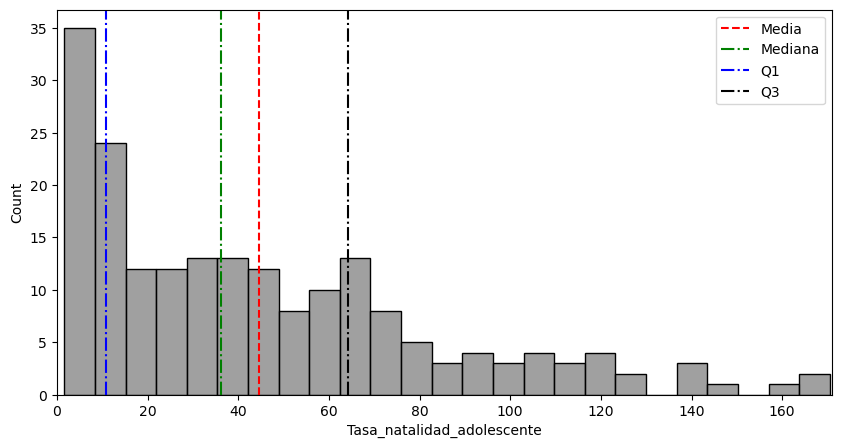

In [143]:
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn

fig, axes = plt.subplots(nrows = 1,figsize=(10,5))

seaborn.histplot(df['Tasa_natalidad_adolescente'],bins=25,color='gray')

plt.xlim(0,171)

axes.axvline(df['Tasa_natalidad_adolescente'].mean(),color='red', linestyle = '--',label='Media')
axes.axvline(df['Tasa_natalidad_adolescente'].median(),color='green', linestyle = '-.',label='Mediana')
axes.axvline(df['Tasa_natalidad_adolescente'].quantile(0.25),color='blue', linestyle = '-.',label='Q1')
axes.axvline(df['Tasa_natalidad_adolescente'].quantile(0.75),color='black', linestyle = '-.',label='Q3')

axes.legend()

#seaborn.despine()

- Observa la media de los datos. ¿Se encuentra en el centro de ellos?
- Compara con lo que ocurre si construimos un histograma con los datos correspondientes a la fuerza laboral masculina.

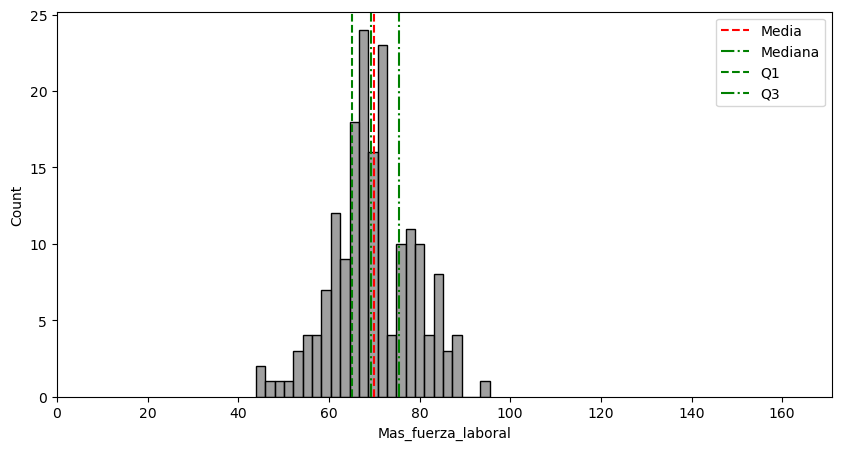

In [157]:
fig, axes = plt.subplots(nrows = 1,figsize=(10,5))
seaborn.histplot(df['Mas_fuerza_laboral'],bins=25,color='gray')
plt.xlim(0,171)

axes.axvline(df['Mas_fuerza_laboral'].mean(),color='red', linestyle = '--',label='Media')

axes.axvline(df['Mas_fuerza_laboral'].median(),color='green', linestyle = '-.',label='Mediana')

axes.axvline(df['Mas_fuerza_laboral'].quantile(0.25),color='green', linestyle = '--',label='Q1')

axes.axvline(df['Mas_fuerza_laboral'].quantile(0.75),color='green', linestyle = '-.',label='Q3')

axes.legend()


- En qué caso las medidas de tendencia central son, efectivamente, más "de tendencia central"?

Compara, ahora, si construimos los boxplot correspondientes a estos datos.

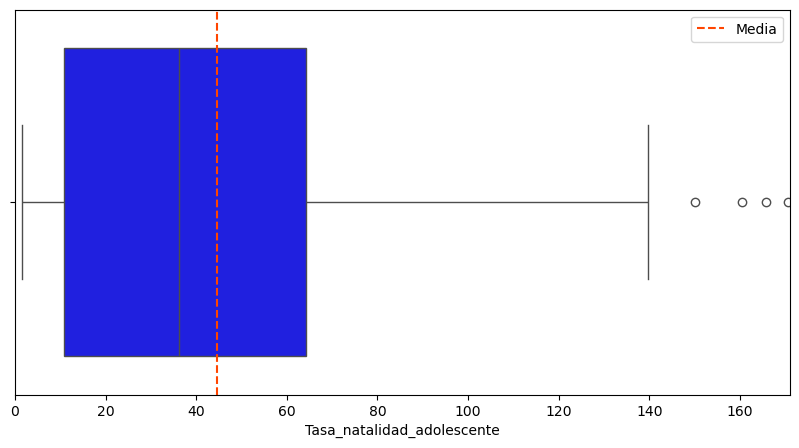

In [160]:
fig, axes = plt.subplots(nrows = 1,figsize=(10,5))
seaborn.boxplot(df['Tasa_natalidad_adolescente'],color='blue',orient='h')
plt.xlim(0,171)
axes.axvline(df['Tasa_natalidad_adolescente'].mean(),color='orangered', linestyle = '--',label='Media')
axes.legend()

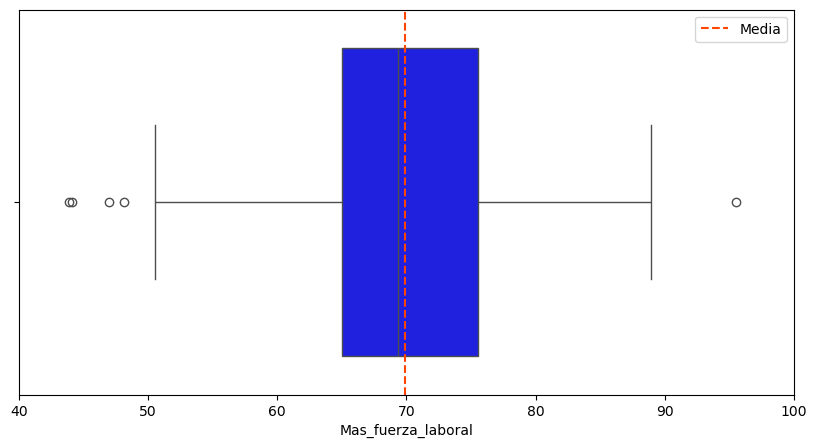

In [164]:
fig, axes = plt.subplots(nrows = 1,figsize=(10,5))
seaborn.boxplot(df['Mas_fuerza_laboral'],color='blue',orient='h')
plt.xlim(40,100)
axes.axvline(df['Mas_fuerza_laboral'].mean(),color='orangered', linestyle = '--',label='Media')
axes.legend()

## <font color='green'>Indicadores agrupados y tablas pivote</font>

En ocasiones, puede ser conveniente agrupar los datos y observar los indicadores por categorías, ya que los comportamientos de cada grupo pueden ser esencialmente diferentes. Por ejemplo, podemos comparar el promedio de porcentaje de participación parlamentaria según el ránking de desarrollo, y de la misma manera, comparar el nivel de educación femenina.

In [167]:
df.Desarrollo_humano.unique()

array(['Very high', 'High', 'Medium', 'Low', nan], dtype=object)

In [169]:
media_parlamento_por_nivel= df.groupby('Desarrollo_humano')['Escanos_parlamento'].mean()
print(media_parlamento_por_nivel)

Desarrollo_humano
High         24.247917
Low          22.700000
Medium       20.975000
Very high    28.741538
Name: Escanos_parlamento, dtype: float64


In [171]:
df.Desarrollo_humano.unique()

array(['Very high', 'High', 'Medium', 'Low', nan], dtype=object)

In [175]:
media_educ_fem_por_nivel= df.groupby('Desarrollo_humano')['Fem_educacion_secundaria'].mean()
print(media_educ_fem_por_nivel)

Desarrollo_humano
High         73.629545
Low          18.606667
Medium       46.073684
Very high    85.390769
Name: Fem_educacion_secundaria, dtype: float64


- ¿En qué casos se observan mayores diferencias?
- Interpreta y discute las diferencias de los valores obtenidos.

Podemos tambiṕen construir tablas pivotes agrupando datos según indicadores, lo que nos permitirá realizar comparaciones más rápidas y efectivas para la interpretación.

In [180]:
df.Fem_educacion_secundaria

0      96.9
1      99.1
2      99.8
3      77.1
4      94.6
       ... 
190    26.5
191     NaN
192     NaN
193     NaN
194     NaN
Name: Fem_educacion_secundaria, Length: 195, dtype: float64

In [184]:
tabla_pivote = pd.pivot_table(df,
                              values=['Fem_educacion_secundaria', 'Mas_educacion_secundaria'], 
                              index='Desarrollo_humano',
                              aggfunc=['mean', 'std', 'count'])
print(tabla_pivote)

                                      mean                           \
                  Fem_educacion_secundaria Mas_educacion_secundaria   
Desarrollo_humano                                                     
High                             73.629545                74.597727   
Low                              18.606667                29.953333   
Medium                           46.073684                52.760526   
Very high                        85.390769                87.466154   

                                       std                           \
                  Fem_educacion_secundaria Mas_educacion_secundaria   
Desarrollo_humano                                                     
High                             17.335266                17.868805   
Low                              10.130866                13.462457   
Medium                           22.373158                19.920023   
Very high                        13.397245                13.001842   

    

In [186]:
tabla_pivote

mean                           \
                  Fem_educacion_secundaria Mas_educacion_secundaria   
Desarrollo_humano                                                     
High                             73.629545                74.597727   
Low                              18.606667                29.953333   
Medium                           46.073684                52.760526   
Very high                        85.390769                87.466154   

                                       std                           \
                  Fem_educacion_secundaria Mas_educacion_secundaria   
Desarrollo_humano                                                     
High                             17.335266                17.868805   
Low                              10.130866                13.462457   
Medium                           22.373158                19.920023   
Very high                        13.397245                13.001842   

                                     count                           
                  Fem_educacion_secundaria Mas_educacion_secundaria  
Desarrollo_humano                                                    
High                                    44                       44  
Low                                     30                       30  
Medium                                  38                       38  
Very high                               65                       65

- ¿Para qué nivel de desarrollo hay mayor diferencia entre las medias?
- Interpreta los resultados para el nivel muy alto (Very high), y compara con los demás. ¿Qué puedes concluir?